# Temperature Dataset EDA

A simple notebook for toying with EDA and visualisations for the OpenWeatherMap dataset.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="white", context="notebook")

In [6]:
# Load data
data = pd.read_csv('data/Daily_Temp_Data.csv')
data['date'] = pd.to_datetime(data['date'], dayfirst=True) # Ensure date is in datetime format

In [ ]:
original_data = pd.read_csv('data/Original_Data.csv')
print(original_data.shape)
print(original_data.columns)
original_data.tail()

(403303, 28)
Index(['dt', 'dt_iso', 'timezone', 'city_name', 'lat', 'lon', 'temp',
       'visibility', 'dew_point', 'feels_like', 'temp_min', 'temp_max',
       'pressure', 'sea_level', 'grnd_level', 'humidity', 'wind_speed',
       'wind_deg', 'wind_gust', 'rain_1h', 'rain_3h', 'snow_1h', 'snow_3h',
       'clouds_all', 'weather_id', 'weather_main', 'weather_description',
       'weather_icon'],
      dtype='object')


,dt,dt_iso,timezone,city_name,lat,lon,temp,visibility,dew_point,feels_like,...,wind_gust,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
403298,1726686000,2024-09-18 19:00:00 +0000 UTC,36000,Brisbane,-27.470453,153.026034,13.97,10000.0,12.53,13.80,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01n
403299,1726689600,2024-09-18 20:00:00 +0000 UTC,36000,Brisbane,-27.470453,153.026034,14.08,10000.0,12.80,13.95,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d
403300,1726693200,2024-09-18 21:00:00 +0000 UTC,36000,Brisbane,-27.470453,153.026034,14.94,NaN,13.65,14.89,...,3.03,NaN,NaN,NaN,NaN,48,802,Clouds,scattered clouds,03d
403301,1726696800,2024-09-18 22:00:00 +0000 UTC,36000,Brisbane,-27.470453,153.026034,17.42,10000.0,15.06,17.46,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d
403302,1726700400,2024-09-18 23:00:00 +0000 UTC,36000,Brisbane,-27.470453,153.026034,20.90,10000.0,15.88,20.95,...,NaN,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d


In [4]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403303 entries, 0 to 403302
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt                   403303 non-null  int64  
 1   dt_iso               403303 non-null  object 
 2   timezone             403303 non-null  int64  
 3   city_name            403303 non-null  object 
 4   lat                  403303 non-null  float64
 5   lon                  403303 non-null  float64
 6   temp                 403303 non-null  float64
 7   visibility           327860 non-null  float64
 8   dew_point            403303 non-null  float64
 9   feels_like           403303 non-null  float64
 10  temp_min             403303 non-null  float64
 11  temp_max             403303 non-null  float64
 12  pressure             403303 non-null  int64  
 13  sea_level            0 non-null       float64
 14  grnd_level           0 non-null       float64
 15  humidity         

In [14]:
print(data.shape)
print(data.info())
data.head()

(16699, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16699 entries, 0 to 16698
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    16699 non-null  datetime64[ns]
 1   temp    16699 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 261.0 KB
None


,date,temp
0,1979-01-01,23.410714
1,1979-01-02,23.031667
2,1979-01-03,23.585833
3,1979-01-04,23.314583
4,1979-01-05,23.267083


In [19]:
# Filter for 2010-2020
filtered = data[(data['date'] >= '2010-01-01') & (data['date'] <= '2020-12-31')]
filtered.head()

,date,temp
11323,2010-01-01,25.246667
11324,2010-01-02,25.962083
11325,2010-01-03,25.663333
11326,2010-01-04,24.607500
11327,2010-01-05,24.012917


In [18]:
filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4018 entries, 11323 to 15340
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4018 non-null   datetime64[ns]
 1   temp    4018 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 94.2 KB


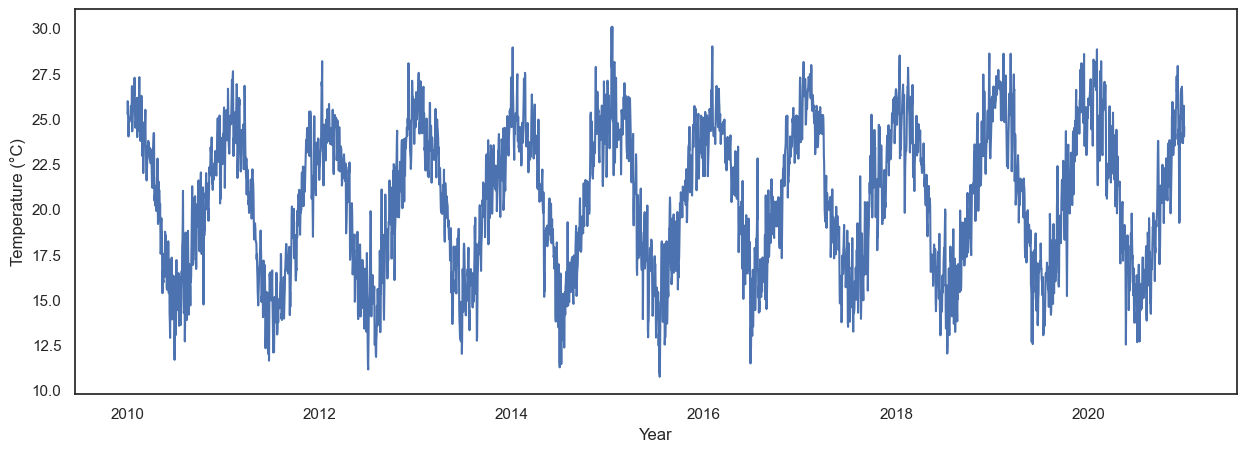

In [27]:
plt.figure(figsize=(15,5))
sns.lineplot(data=filtered, x="date", y="temp")
# plt.title('Daily Temperature (2010–2020)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
# plt.grid(True)
# plt.tight_layout()
plt.show()

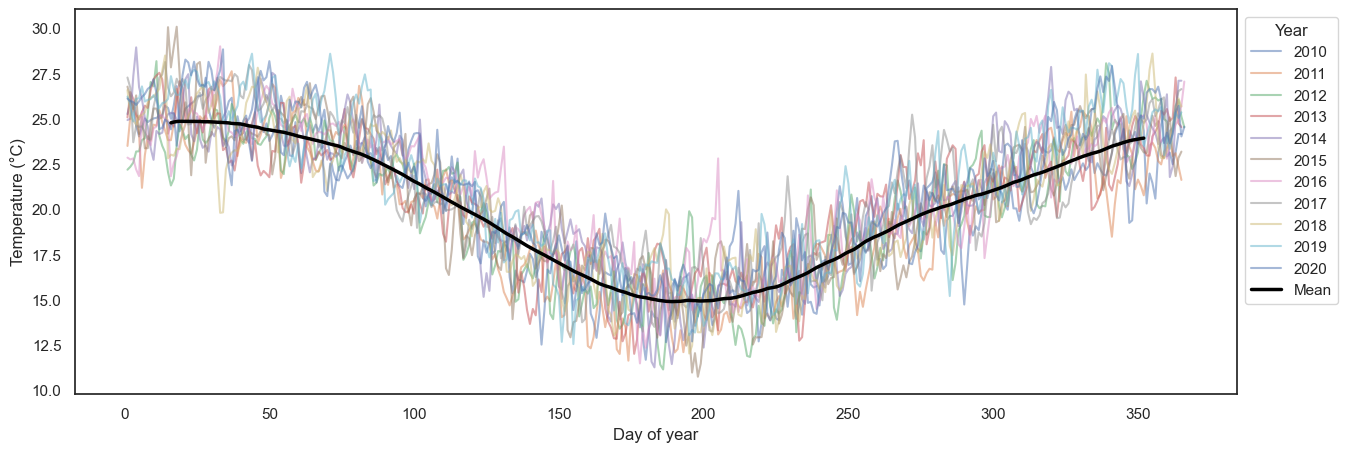

In [ ]:
# Year-based plot with smoothing on average 

plt.figure(figsize=(15, 5))

# Add individual year plots
for y, d in data.groupby(filtered.date.dt.year):
    # d = d.sort_values('date')
    # smoothed = d['temp'].rolling(window=7, center=True).mean()
    sns.lineplot(x=d.date.dt.dayofyear, y=d.temp, label=str(int(y)), alpha=0.5)

# Add smoothed mean curve
data['dayofyear'] = data['date'].dt.dayofyear
mean_curve = data.groupby('dayofyear')['temp'].mean().rolling(window=30, center=True).mean()
sns.lineplot(x=mean_curve.index, y=mean_curve.values, color='black', linewidth=2.5, label='Mean')

# Labels and layout
# plt.title('Daily Temperature (2010–2020) with Mean Curve')
plt.xlabel('Day of year')
plt.ylabel('Temperature (°C)')
plt.legend(title='Year', bbox_to_anchor=(1, 1), loc='upper left')
# plt.grid(True)
# plt.tight_layout()
plt.show()